In [3]:
# Volatility Analysis for OHLC Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

In [5]:
# Load data
data = pd.read_csv('../data/aapl.us.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')
# Use last 500 days for analysis
data = data.tail(500)
print(f"Data range: {data.index.min()} to {data.index.max()}")
print(f"Total days: {len(data)}")

Data range: 2015-11-18 00:00:00 to 2017-11-10 00:00:00
Total days: 500


In [6]:
# Display first few rows
data.head()

,Open,High,Low,Close,Volume,OpenInt
Date,,,,,,
2015-11-18,111.45,113.10,111.19,112.91,48480343,0
2015-11-19,113.25,115.29,112.42,114.36,44970842,0
2015-11-20,114.77,115.45,114.42,114.86,35613492,0
2015-11-23,114.83,115.27,112.95,113.35,33739180,0
2015-11-24,112.95,114.91,112.77,114.45,44451376,0


## 1. Historical Volatility (Standard Deviation)

In [7]:
def calculate_historical_volatility(prices, window=20, annual_factor=252):
    """
    Calculate annualized historical volatility

    Parameters:
    - prices: Price series (typically Close)
    - window: Rolling window period
    - annual_factor: 252 for daily, 52 for weekly
    """
    returns = prices.pct_change()
    volatility = returns.rolling(window).std() * np.sqrt(annual_factor)
    return volatility

# Calculate different window volatilities
data['volatility_10'] = calculate_historical_volatility(data['Close'], window=10)
data['volatility_20'] = calculate_historical_volatility(data['Close'], window=20)
data['volatility_30'] = calculate_historical_volatility(data['Close'], window=30)
data['volatility_60'] = calculate_historical_volatility(data['Close'], window=60)

# Calculate returns for later use
data['returns'] = data['Close'].pct_change()

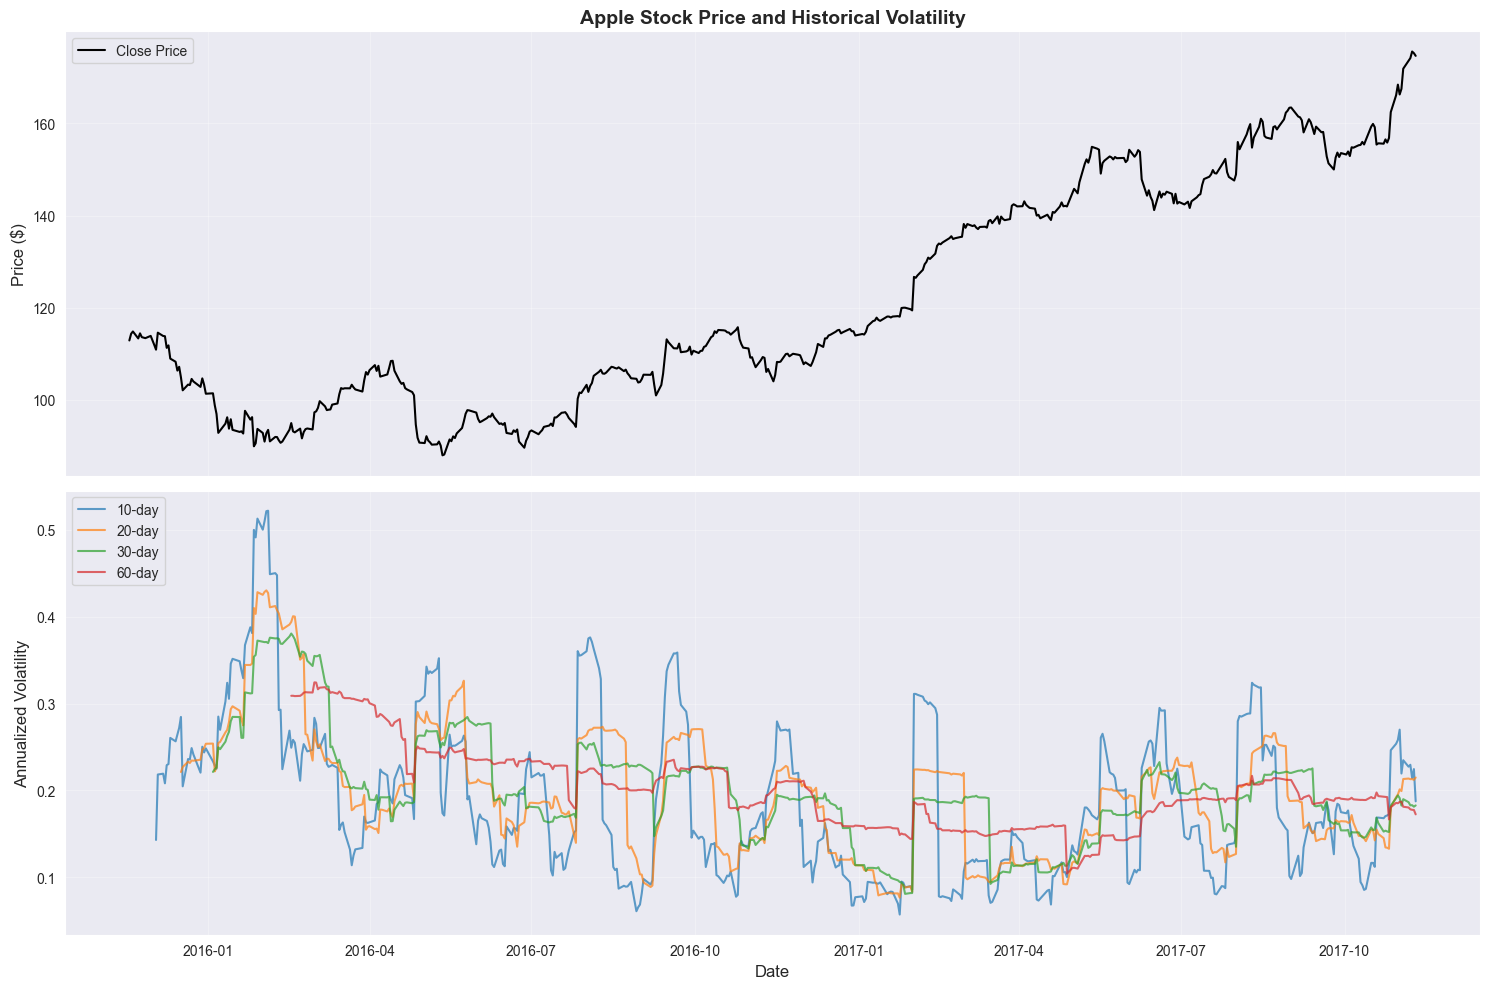

In [8]:
# Plot historical volatility
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Price chart
ax1.plot(data.index, data['Close'], label='Close Price', color='black', linewidth=1.5)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.set_title('Apple Stock Price and Historical Volatility', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Volatility chart
ax2.plot(data.index, data['volatility_10'], label='10-day', alpha=0.7)
ax2.plot(data.index, data['volatility_20'], label='20-day', alpha=0.7)
ax2.plot(data.index, data['volatility_30'], label='30-day', alpha=0.7)
ax2.plot(data.index, data['volatility_60'], label='60-day', alpha=0.7)
ax2.set_ylabel('Annualized Volatility', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Average True Range (ATR)

In [9]:
# Calculate ATR for different periods
data['atr_7'] = talib.ATR(data['High'], data['Low'], data['Close'], timeperiod=7)
data['atr_14'] = talib.ATR(data['High'], data['Low'], data['Close'], timeperiod=14)
data['atr_21'] = talib.ATR(data['High'], data['Low'], data['Close'], timeperiod=21)

# Calculate ATR as percentage of close price
data['atr_pct_14'] = (data['atr_14'] / data['Close']) * 100

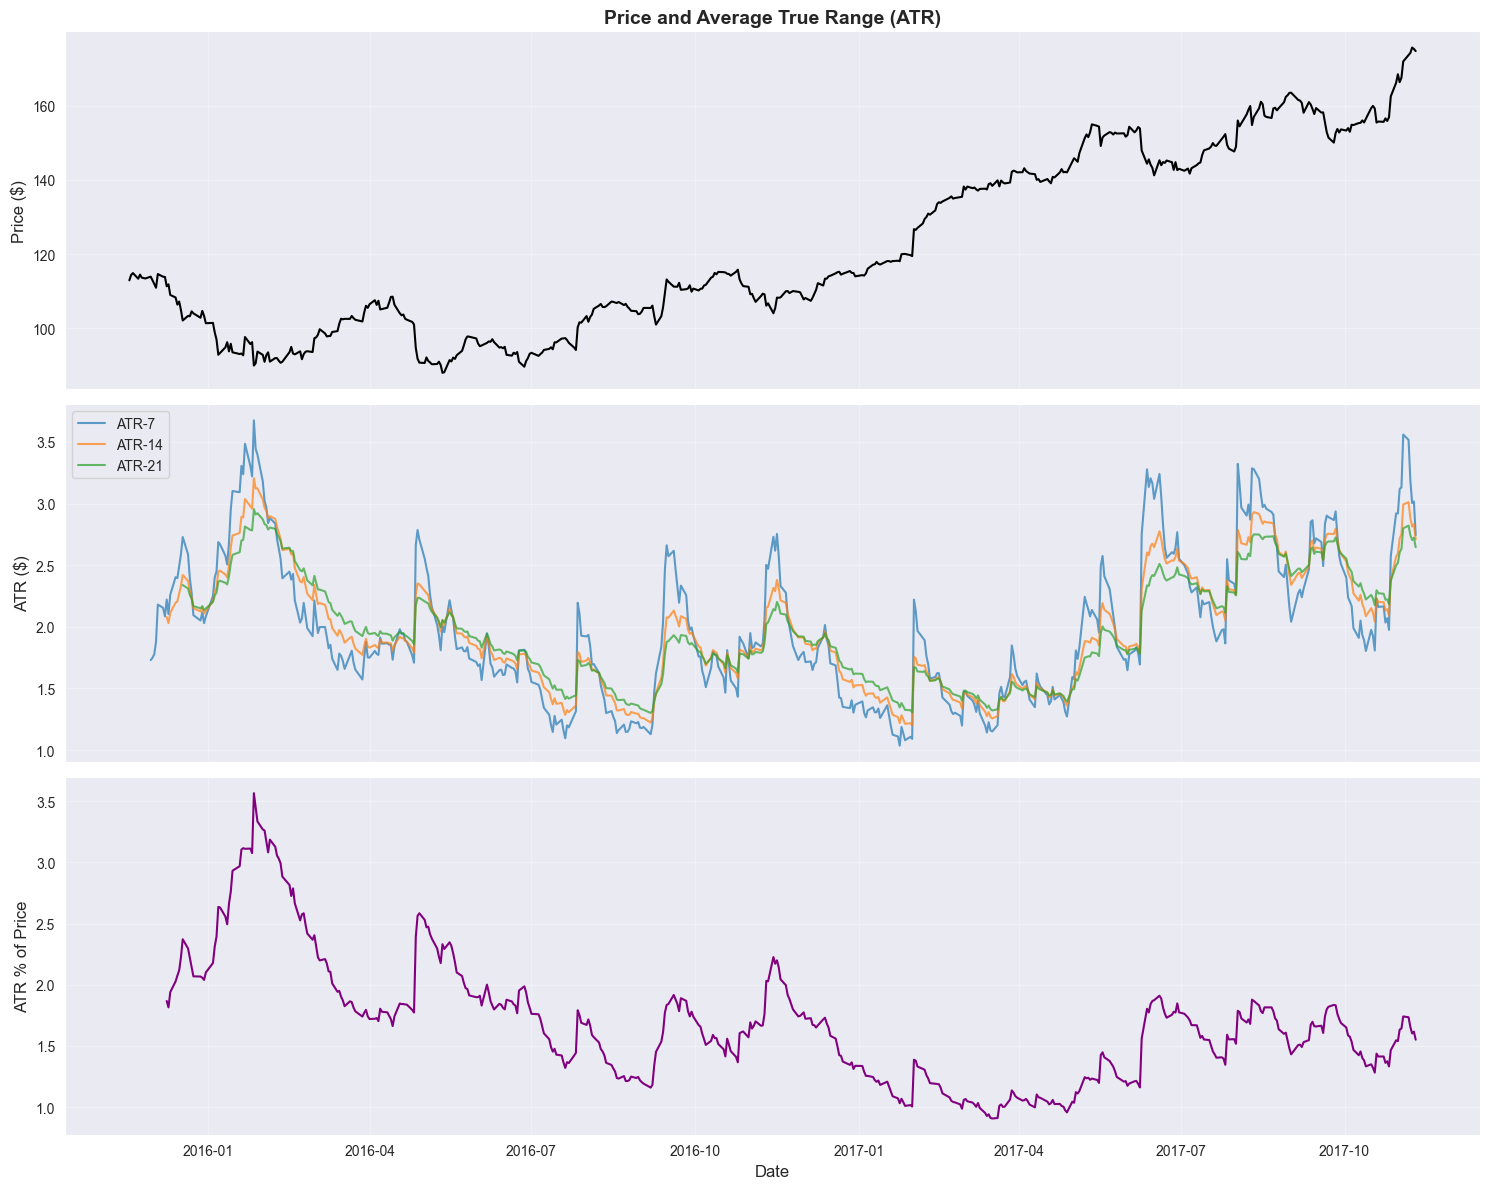

In [10]:
# Plot ATR
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Price
ax1.plot(data.index, data['Close'], color='black', linewidth=1.5)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.set_title('Price and Average True Range (ATR)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# ATR (absolute)
ax2.plot(data.index, data['atr_7'], label='ATR-7', alpha=0.7)
ax2.plot(data.index, data['atr_14'], label='ATR-14', alpha=0.7)
ax2.plot(data.index, data['atr_21'], label='ATR-21', alpha=0.7)
ax2.set_ylabel('ATR ($)', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# ATR as percentage
ax3.plot(data.index, data['atr_pct_14'], color='purple', linewidth=1.5)
ax3.set_ylabel('ATR % of Price', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Bollinger Bands (Volatility Bands)

In [11]:
# Calculate Bollinger Bands
period = 20
std_dev = 2

data['bb_upper'], data['bb_middle'], data['bb_lower'] = talib.BBANDS(
    data['Close'], timeperiod=period, nbdevup=std_dev, nbdevdn=std_dev
)

# Calculate bandwidth (measure of volatility)
data['bb_bandwidth'] = (data['bb_upper'] - data['bb_lower']) / data['bb_middle']

# Calculate %B (position within bands)
data['bb_pct'] = (data['Close'] - data['bb_lower']) / (data['bb_upper'] - data['bb_lower'])

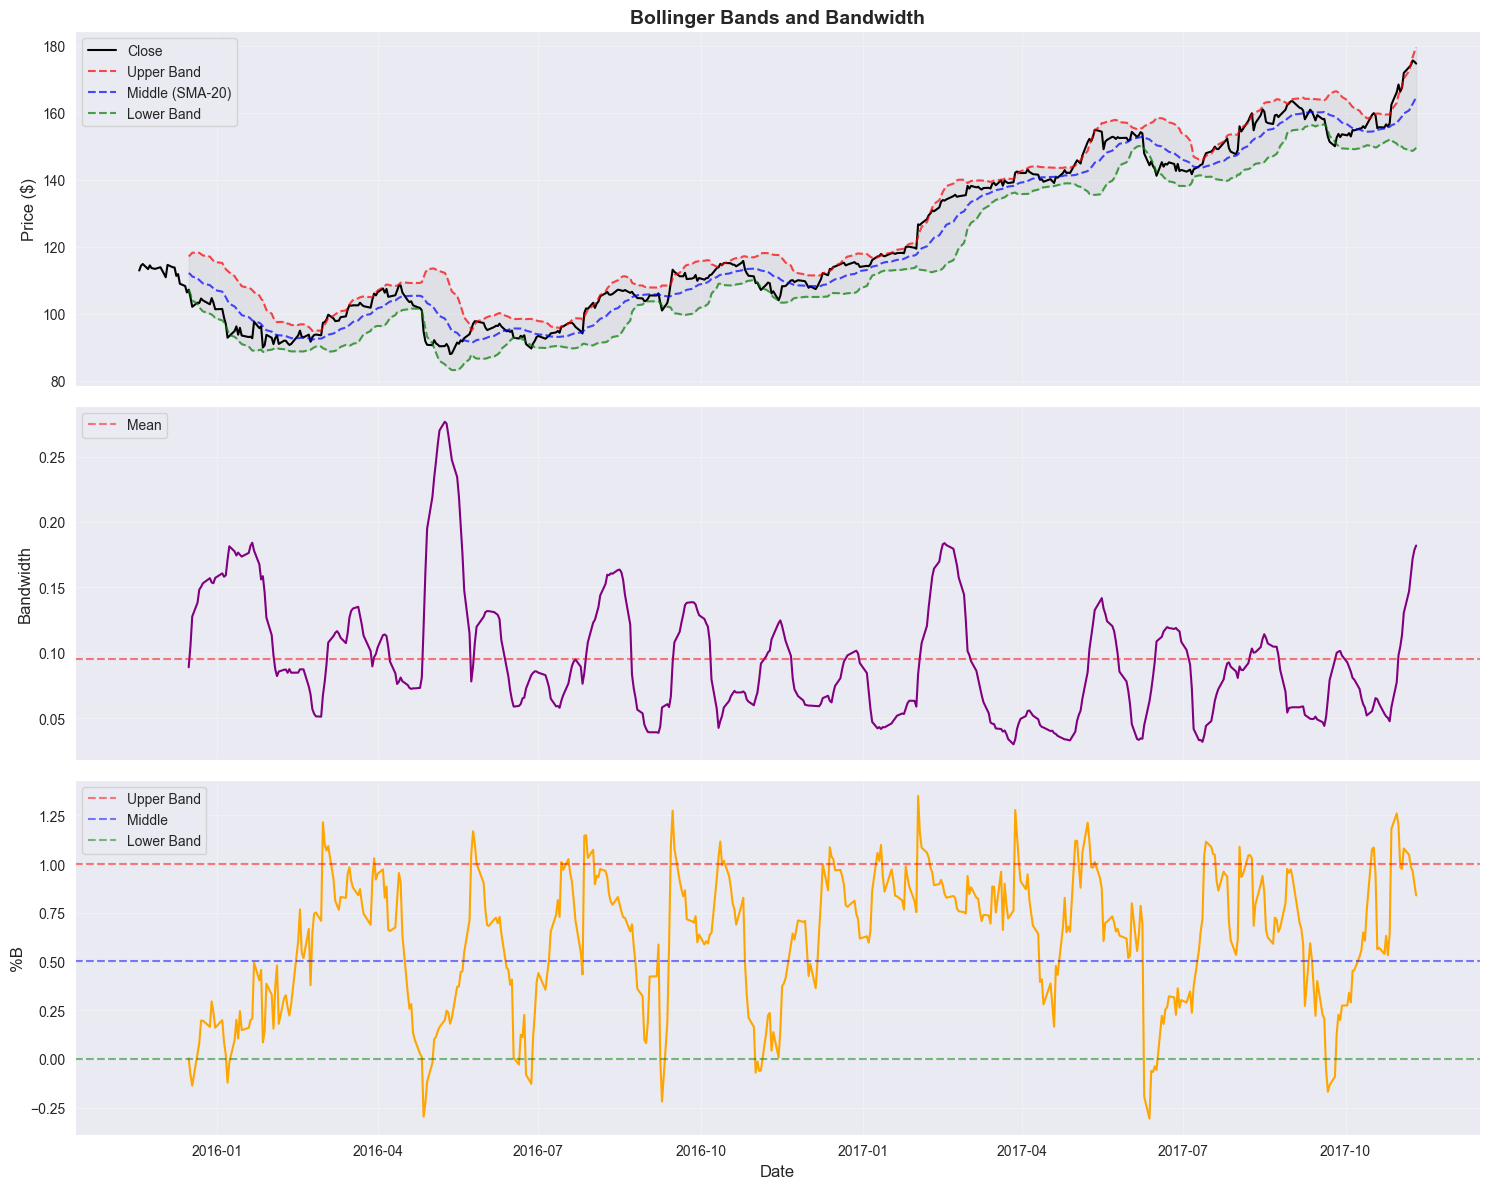

In [12]:
# Plot Bollinger Bands
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Bollinger Bands
ax1.plot(data.index, data['Close'], label='Close', color='black', linewidth=1.5)
ax1.plot(data.index, data['bb_upper'], label='Upper Band', color='red', linestyle='--', alpha=0.7)
ax1.plot(data.index, data['bb_middle'], label='Middle (SMA-20)', color='blue', linestyle='--', alpha=0.7)
ax1.plot(data.index, data['bb_lower'], label='Lower Band', color='green', linestyle='--', alpha=0.7)
ax1.fill_between(data.index, data['bb_lower'], data['bb_upper'], alpha=0.1, color='gray')
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.set_title('Bollinger Bands and Bandwidth', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Bandwidth (volatility indicator)
ax2.plot(data.index, data['bb_bandwidth'], color='purple', linewidth=1.5)
ax2.set_ylabel('Bandwidth', fontsize=12)
ax2.axhline(y=data['bb_bandwidth'].mean(), color='red', linestyle='--', alpha=0.5, label='Mean')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# %B (position within bands)
ax3.plot(data.index, data['bb_pct'], color='orange', linewidth=1.5)
ax3.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Upper Band')
ax3.axhline(y=0.5, color='blue', linestyle='--', alpha=0.5, label='Middle')
ax3.axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Lower Band')
ax3.set_ylabel('%B', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Parkinson's Volatility (High-Low Range)

In [13]:
def parkinson_volatility(high, low, window=20, annual_factor=252):
    """
    Parkinson's volatility estimator using high-low range
    More efficient than close-to-close volatility
    """
    hl_ratio = np.log(high / low)
    parkinson_vol = np.sqrt(hl_ratio**2 / (4 * np.log(2))) * np.sqrt(annual_factor)
    return parkinson_vol.rolling(window).mean()

data['parkinson_vol_20'] = parkinson_volatility(data['High'], data['Low'], window=20)

## 5. Garman-Klass Volatility

In [14]:
def garman_klass_volatility(open_price, high, low, close, window=20, annual_factor=252):
    """
    Garman-Klass volatility estimator
    Uses OHLC data for better estimation
    """
    hl_ratio = np.log(high / low)
    co_ratio = np.log(close / open_price)

    gk_vol = np.sqrt(
        0.5 * hl_ratio**2 - (2 * np.log(2) - 1) * co_ratio**2
    ) * np.sqrt(annual_factor)

    return gk_vol.rolling(window).mean()

data['gk_vol_20'] = garman_klass_volatility(
    data['Open'], data['High'], data['Low'], data['Close'], window=20
)

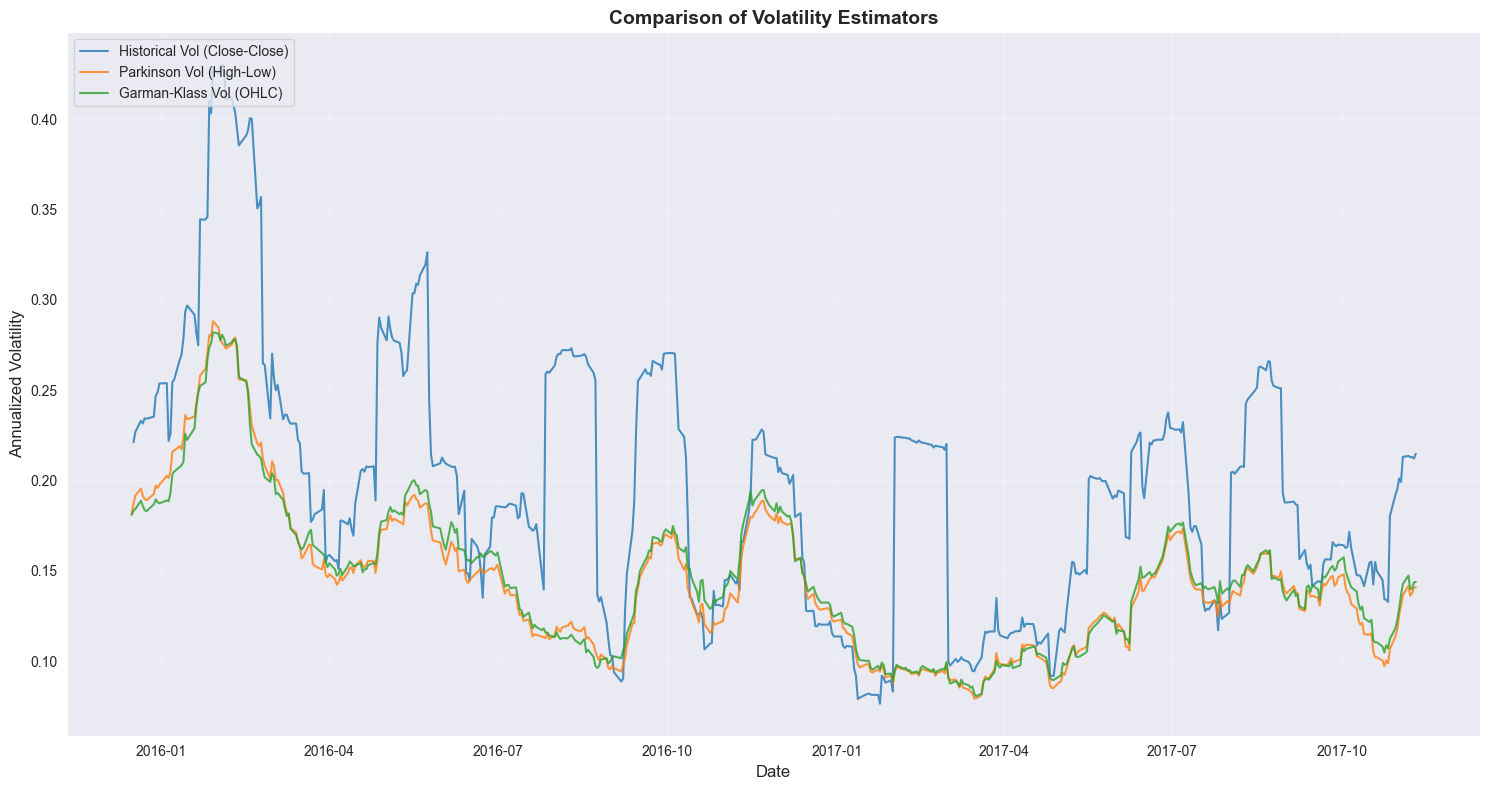

In [15]:
# Compare different volatility measures
fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(data.index, data['volatility_20'], label='Historical Vol (Close-Close)', alpha=0.8)
ax.plot(data.index, data['parkinson_vol_20'], label='Parkinson Vol (High-Low)', alpha=0.8)
ax.plot(data.index, data['gk_vol_20'], label='Garman-Klass Vol (OHLC)', alpha=0.8)

ax.set_ylabel('Annualized Volatility', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Comparison of Volatility Estimators', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Volatility Distribution and Statistics

In [16]:
# Calculate statistics for 20-day historical volatility
vol_stats = {
    'Mean': data['volatility_20'].mean(),
    'Median': data['volatility_20'].median(),
    'Std Dev': data['volatility_20'].std(),
    'Min': data['volatility_20'].min(),
    'Max': data['volatility_20'].max(),
    'Current': data['volatility_20'].iloc[-1]
}

print("20-Day Historical Volatility Statistics:")
print("="*50)
for key, value in vol_stats.items():
    print(f"{key:15s}: {value:.4f}")

20-Day Historical Volatility Statistics:
Mean           : 0.1962
Median         : 0.1928
Std Dev        : 0.0718
Min            : 0.0763
Max            : 0.4303
Current        : 0.2147


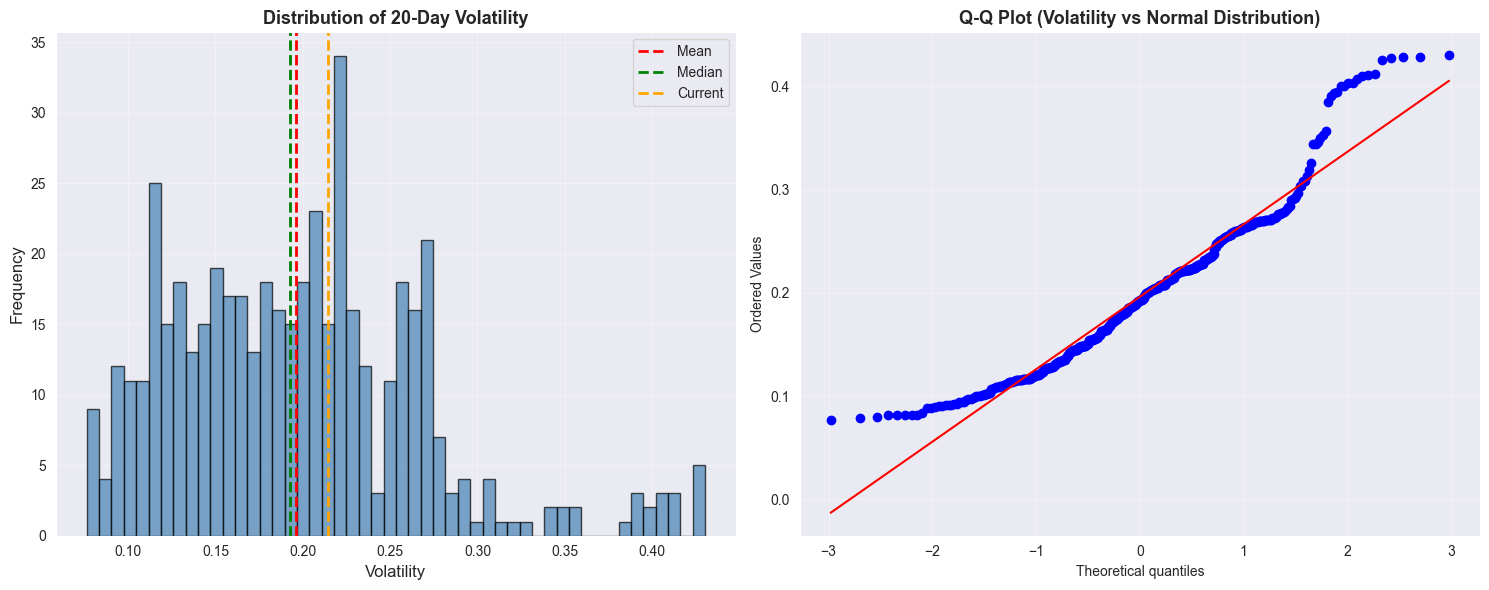

In [17]:
# Plot distribution of volatility
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
ax1.hist(data['volatility_20'].dropna(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(data['volatility_20'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
ax1.axvline(data['volatility_20'].median(), color='green', linestyle='--', linewidth=2, label='Median')
ax1.axvline(data['volatility_20'].iloc[-1], color='orange', linestyle='--', linewidth=2, label='Current')
ax1.set_xlabel('Volatility', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of 20-Day Volatility', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(data['volatility_20'].dropna(), dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Volatility vs Normal Distribution)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Rolling Volatility Percentiles

In [18]:
# Calculate percentile ranks
data['vol_percentile'] = data['volatility_20'].rolling(window=252).apply(
    lambda x: stats.percentileofscore(x, x.iloc[-1]) if len(x) == 252 else np.nan
)

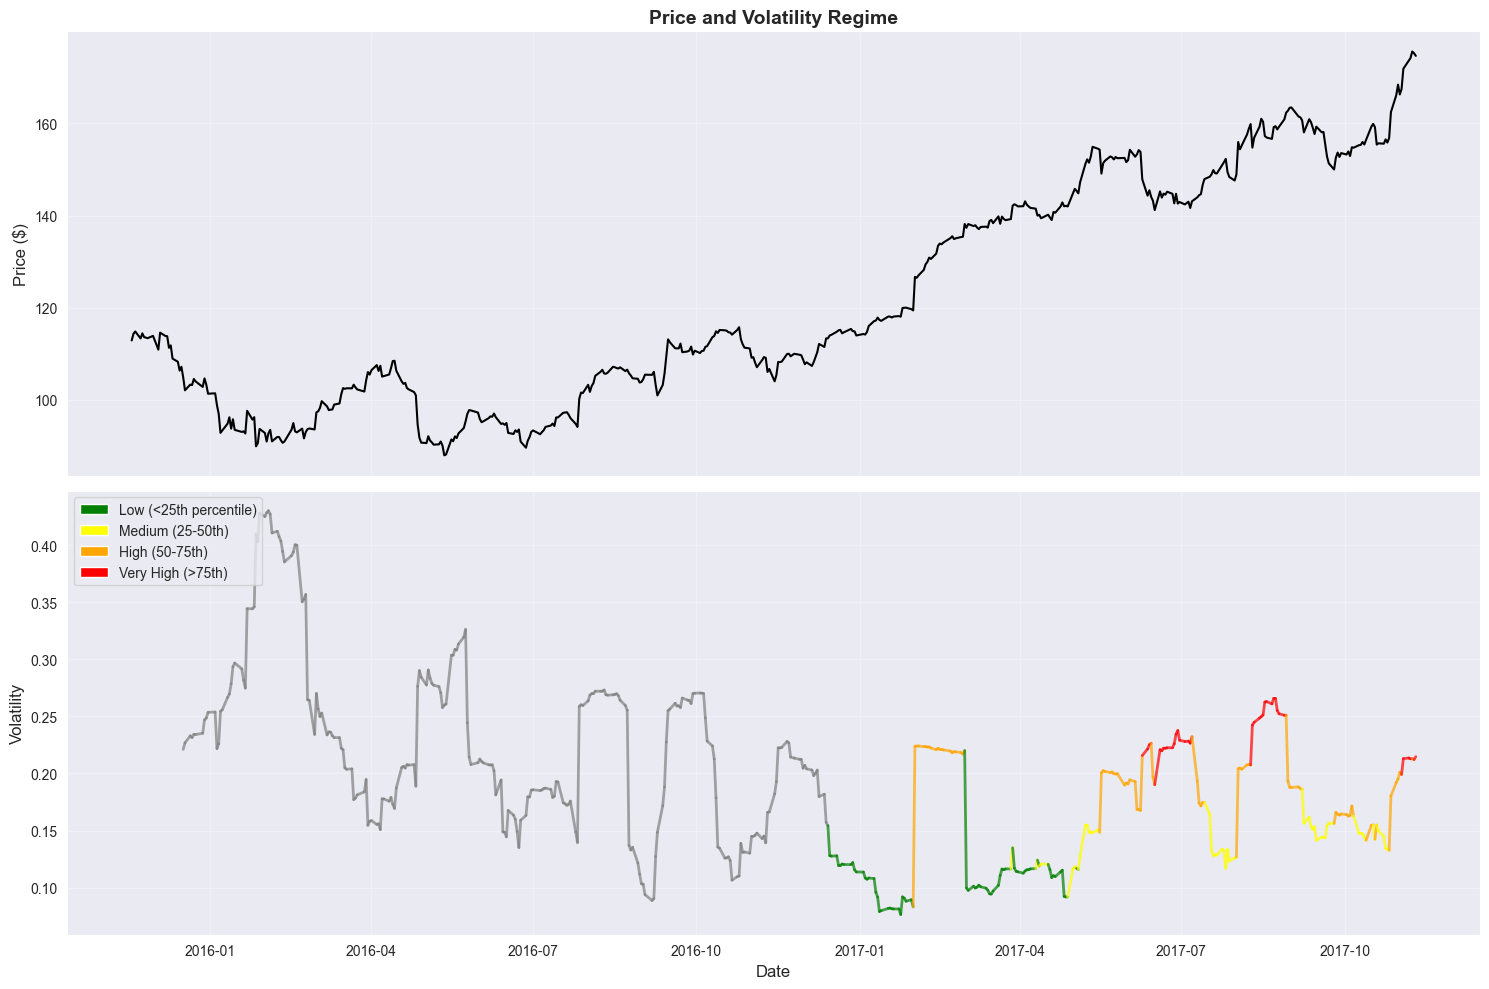

In [19]:
# Plot volatility with percentile coloring
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Price
ax1.plot(data.index, data['Close'], color='black', linewidth=1.5)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.set_title('Price and Volatility Regime', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Volatility with percentile coloring
colors = []
for val in data['vol_percentile']:
    if pd.isna(val):
        colors.append('gray')
    elif val < 25:
        colors.append('green')
    elif val < 50:
        colors.append('yellow')
    elif val < 75:
        colors.append('orange')
    else:
        colors.append('red')

for i in range(1, len(data)):
    ax2.plot(data.index[i-1:i+1], data['volatility_20'].iloc[i-1:i+1],
             color=colors[i], linewidth=2, alpha=0.7)

ax2.set_ylabel('Volatility', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='Low (<25th percentile)'),
    Patch(facecolor='yellow', label='Medium (25-50th)'),
    Patch(facecolor='orange', label='High (50-75th)'),
    Patch(facecolor='red', label='Very High (>75th)')
]
ax2.legend(handles=legend_elements, loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Volatility Clustering Analysis

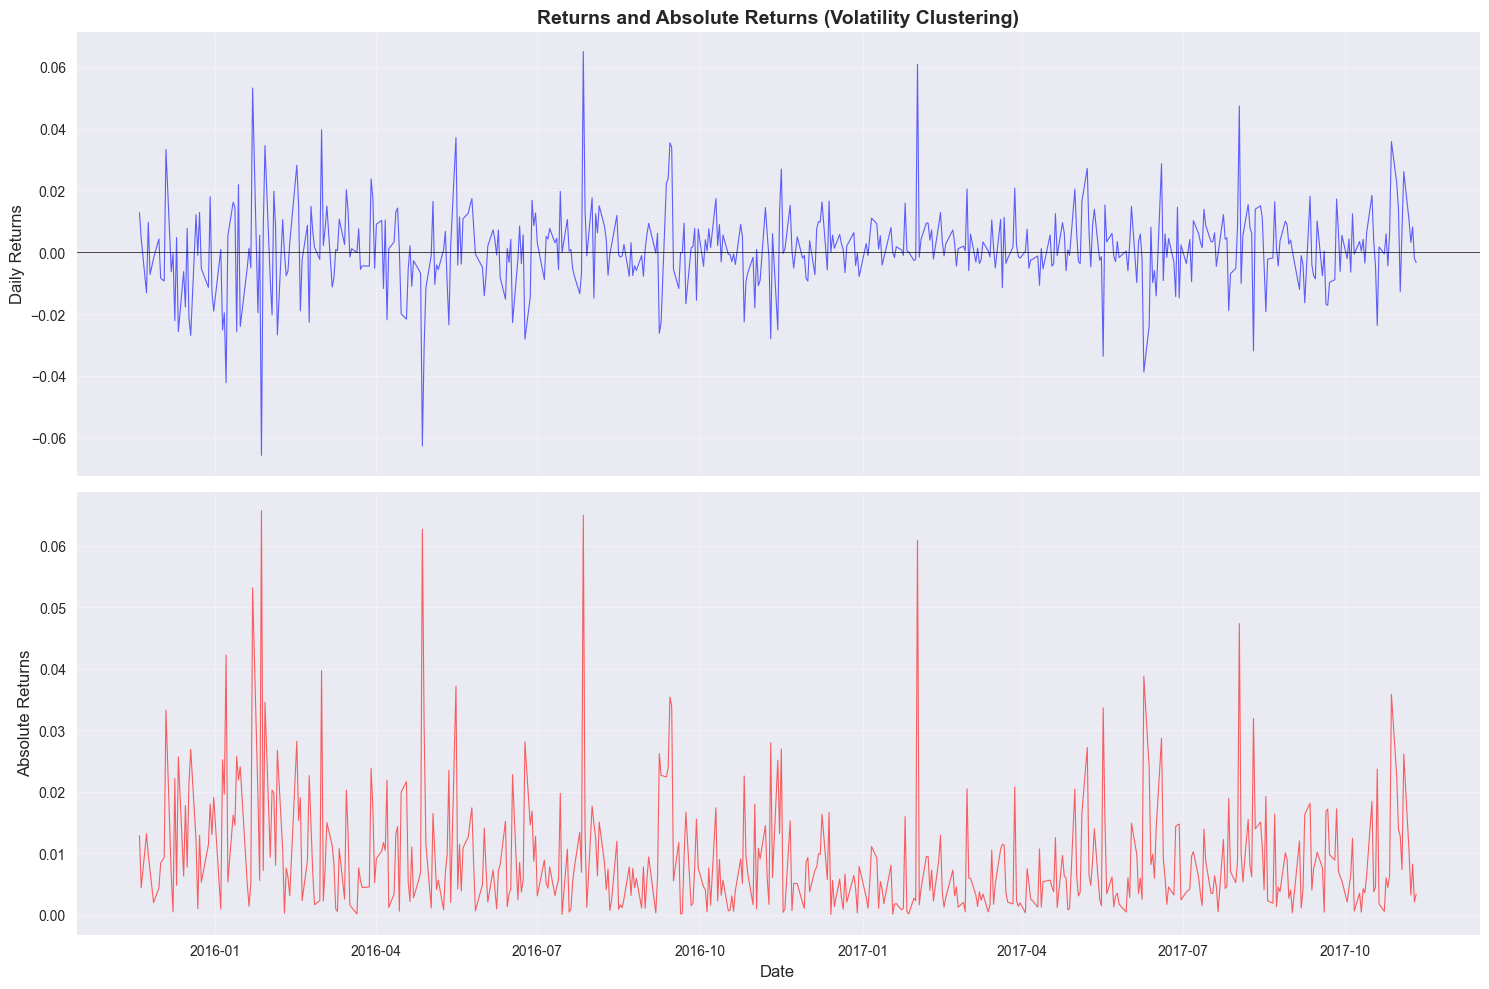

In [20]:
# Plot absolute returns (proxy for volatility clustering)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Returns
ax1.plot(data.index, data['returns'], color='blue', alpha=0.6, linewidth=0.8)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_ylabel('Daily Returns', fontsize=12)
ax1.set_title('Returns and Absolute Returns (Volatility Clustering)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Absolute returns
ax2.plot(data.index, data['returns'].abs(), color='red', alpha=0.6, linewidth=0.8)
ax2.set_ylabel('Absolute Returns', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Volatility Cone (Expected Future Volatility)

In [21]:
# Calculate realized volatility for different windows
windows = [5, 10, 20, 30, 60, 90]
percentiles = [10, 25, 50, 75, 90]

vol_cone_data = []

for window in windows:
    vol = calculate_historical_volatility(data['Close'], window=window)
    vol_cone_data.append({
        'window': window,
        'current': vol.iloc[-1],
        **{f'p{p}': vol.quantile(p/100) for p in percentiles}
    })

vol_cone_df = pd.DataFrame(vol_cone_data)

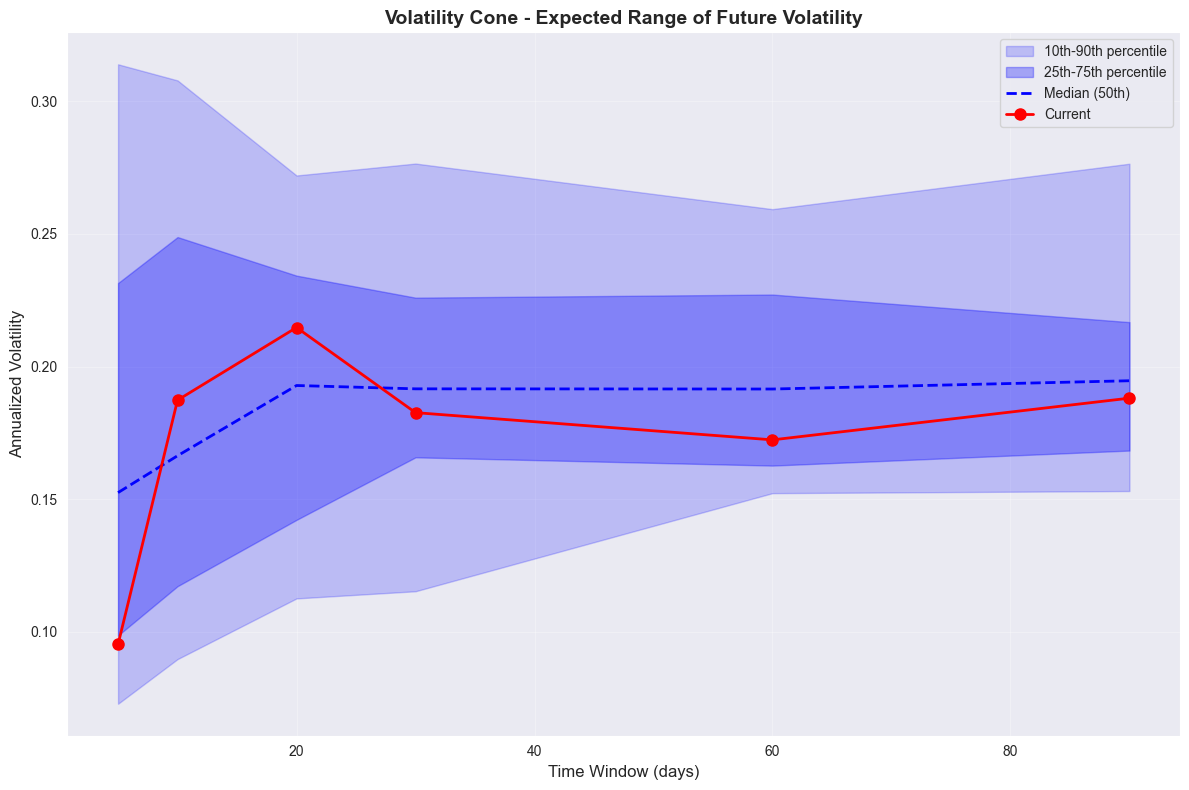

In [22]:
# Plot volatility cone
fig, ax = plt.subplots(figsize=(12, 8))

ax.fill_between(vol_cone_df['window'], vol_cone_df['p10'], vol_cone_df['p90'],
                alpha=0.2, color='blue', label='10th-90th percentile')
ax.fill_between(vol_cone_df['window'], vol_cone_df['p25'], vol_cone_df['p75'],
                alpha=0.3, color='blue', label='25th-75th percentile')
ax.plot(vol_cone_df['window'], vol_cone_df['p50'], 'b--', linewidth=2, label='Median (50th)')
ax.plot(vol_cone_df['window'], vol_cone_df['current'], 'ro-', linewidth=2, markersize=8, label='Current')

ax.set_xlabel('Time Window (days)', fontsize=12)
ax.set_ylabel('Annualized Volatility', fontsize=12)
ax.set_title('Volatility Cone - Expected Range of Future Volatility', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Display volatility cone table
print("\nVolatility Cone Table:")
print("="*80)
print(vol_cone_df.to_string(index=False))


Volatility Cone Table:
 window  current      p10      p25      p50      p75      p90
      5 0.095171 0.072775 0.098532 0.152429 0.231481 0.314009
     10 0.187309 0.089616 0.117121 0.166334 0.248838 0.307936
     20 0.214717 0.112508 0.142144 0.192833 0.234288 0.272071
     30 0.182598 0.115213 0.165738 0.191579 0.225975 0.276568
     60 0.172328 0.152222 0.162619 0.191506 0.227147 0.259364
     90 0.188062 0.153027 0.168292 0.194629 0.216746 0.276505


## 10. Summary Statistics

In [24]:
# Create comprehensive summary
summary = pd.DataFrame({
    'Metric': [
        'Current Price',
        'Current Vol (20-day)',
        'Mean Vol (20-day)',
        'Vol Percentile',
        'ATR-14',
        'ATR % of Price',
        'BB Bandwidth',
        'High-Low Range (Avg)',
        'Max Vol (period)',
        'Min Vol (period)'
    ],
    'Value': [
        f"${data['Close'].iloc[-1]:.2f}",
        f"{data['volatility_20'].iloc[-1]:.4f}",
        f"{data['volatility_20'].mean():.4f}",
        f"{data['vol_percentile'].iloc[-1]:.1f}%" if not pd.isna(data['vol_percentile'].iloc[-1]) else "N/A",
        f"${data['atr_14'].iloc[-1]:.2f}",
        f"{data['atr_pct_14'].iloc[-1]:.2f}%",
        f"{data['bb_bandwidth'].iloc[-1]:.4f}",
        f"${(data['High'] - data['Low']).mean():.2f}",
        f"{data['volatility_20'].max():.4f}",
        f"{data['volatility_20'].min():.4f}"
    ]
})

print("\n" + "="*60)
print("VOLATILITY SUMMARY")
print("="*60)
print(summary.to_string(index=False))
print("="*60)



VOLATILITY SUMMARY
              Metric   Value
       Current Price $174.67
Current Vol (20-day)  0.2147
   Mean Vol (20-day)  0.1962
      Vol Percentile   77.4%
              ATR-14   $2.71
      ATR % of Price   1.55%
        BB Bandwidth  0.1820
High-Low Range (Avg)   $1.79
    Max Vol (period)  0.4303
    Min Vol (period)  0.0763
